# Premix

## Определение:
- витаминные
- 
- 
- 

In [2]:
import datetime
import pingouin as pg
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phik
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'
sns.set_theme(context='talk', style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = 10, 7
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['figure.titlesize'] = 32
plt.rcParams['axes.titlesize'] = 32
plt.rcParams['savefig.format'] = 'pdf'
plt.rcParams['figure.autolayout'] = 'true'
plt.rcParams['figure.frameon'] = 'false'
plt.rcParams['axes.spines.left'] = 'false'
plt.rcParams['axes.spines.right'] = 'false'
plt.rcParams['axes.spines.top'] = 'false'
plt.rcParams['legend.fancybox'] = 'false'
plt.rcParams['axes.spines.bottom'] = 'false'
plt.rcParams['font.size'] = 20
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
# для графиков, где надо много цветов, юзайте воть:
sns.set_palette(sns.color_palette('deep'))
# а по дефолту воть:
sns.set_palette(sns.color_palette('BuGn_r', n_colors=10)[2::3])
pd.set_option('display.max_columns', 60)

monthly_feeding = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Feeding')
herd_metrics = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Herd maintenance').replace('-', np.nan)
production_indicators = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Dairy indicators').replace('-', np.nan)

herd_metrics["year_month"] = herd_metrics["date"].dt.to_period('M').astype(str)

fad = pd.read_csv("datasets//FeedingAndDetails_clear.csv", index_col=0)

fad["Date"] = pd.to_datetime(fad["Date"])
fad["year_month"] = fad["Date"].dt.to_period('M').astype(str)
fad = fad.rename(columns={"FarmName": "farm_name"})


In [49]:
production_indicators["year_month"] = production_indicators["date"].dt.to_period('M').astype(str)

In [3]:
df = fad.copy()
daily_group = df.groupby(['Date', 'farm_name', 'PhysiologicalGroupName', 'ingredient_name'], as_index=False).agg({
    'PhysicalWeight_kg': 'sum',
    'PhysiologicalGroupHeadCount': 'first'
})
daily_group

,Date,farm_name,PhysiologicalGroupName,ingredient_name,PhysicalWeight_kg,PhysiologicalGroupHeadCount
0,2022-01-01,ЖК Добрино,Д0 (Новотельные),вода,551.000,33
1,2022-01-01,ЖК Добрино,Д0 (Новотельные),глицерин,25.086,33
2,2022-01-01,ЖК Добрино,Д0 (Новотельные),жир защищённый,23.079,33
3,2022-01-01,ЖК Добрино,Д0 (Новотельные),жмых рапсовый,366.000,33
4,2022-01-01,ЖК Добрино,Д0 (Новотельные),комбикорм 10 группы,578.000,33
...,...,...,...,...,...,...
3623807,2025-10-22,РМ Торопово,Т4 (>1 года),клевер + тимофеевка сенаж,4549.000,93
3623808,2025-10-22,РМ Торопово,Т4 (>1 года),кукуруза силос,3520.000,93
3623809,2025-10-22,РМ Торопово,Т4 (>1 года),оболочка сои,422.000,93
3623810,2025-10-22,РМ Торопово,Т4 (>1 года),премикс молодняк 6-24,75.866,93


In [4]:
fad

,FeedingTaskID,Date,farm_name,FeedNumber,SectionID,PhysiologicalGroupID,PhysiologicalGroupName,PhysiologicalGroupHeadCount,Appetite,RationName,RationPart,TotalWeight_kg,CompletedAt,year,PhysicalWeight_kg,ingredient_name,ingredient_group,year_month
0,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,150.259,солома покупная,Объёмные корма,2022-01
1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,880.444,люцерна сенаж,Объёмные корма,2022-01
2,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,542.257,комбикорм 10 группы,Комбикорма и стартеры,2022-01
3,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,991.793,кукуруза сухая,Энергетические и крахмалистые корма,2022-01
4,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,156.054,шрот подсолнечный,Белковые корма,2022-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16411360,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,120.643,солома (общ.),Объёмные корма,2025-10
16411361,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,549.169,люцерна сенаж,Объёмные корма,2025-10
16411362,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,36.676,жом свекловичный сухой,Жом и дробина,2025-10
16411363,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,10.049,премикс молодняк 6-24,"Премиксы, БАДы, дрожжи",2025-10


In [5]:
df = fad.copy()

grouped = df.groupby(
    ["Date", "farm_name", "PhysiologicalGroupName", "year_month"]
)["PhysicalWeight_kg"].sum().reset_index()

dff = df.groupby(["Date", "farm_name", "PhysiologicalGroupName", "SectionID"], as_index=False).agg(
    TrueHeadCount=("PhysiologicalGroupHeadCount", "max")
)

appetites = dff.groupby(
    ["Date", "farm_name", "PhysiologicalGroupName"]
).agg({
    "TrueHeadCount": "sum"
}).reset_index().rename(columns={"TrueHeadCount": "CowCount"})

appetites["CowCount"] = appetites["CowCount"]


date_phy_feeding = pd.merge(
    grouped,
    appetites,
    on=["Date", "farm_name", "PhysiologicalGroupName"],
    how="left"
)
date_phy_feeding["WeightPerCow"] = date_phy_feeding["PhysicalWeight_kg"] / date_phy_feeding["CowCount"]
date_phy_feeding

,Date,farm_name,PhysiologicalGroupName,year_month,PhysicalWeight_kg,CowCount,WeightPerCow
0,2022-01-01,ЖК Добрино,Д0 (Новотельные),2022-01,6076.165,136,44.677684
1,2022-01-01,ЖК Добрино,Д1,2022-01,143544.434,2710,52.968426
2,2022-01-01,ЖК Добрино,Д2,2022-01,16102.000,345,46.672464
3,2022-01-01,ЖК Добрино,Нетели,2022-01,29691.786,1245,23.848824
4,2022-01-01,ЖК Добрино,С1,2022-01,5237.236,172,30.449047
...,...,...,...,...,...,...,...
520366,2025-10-22,РМ Поляна,Т2 (6-8 мес.),2025-10,2773.000,175,15.845714
520367,2025-10-22,РМ Поляна,Т3 (9-12 мес.),2025-10,3196.000,158,20.227848
520368,2025-10-22,РМ Торопово,Нетели,2025-10,26393.897,988,26.714471
520369,2025-10-22,РМ Торопово,Т3 (9-12 мес.),2025-10,2932.291,150,19.548607


In [9]:
fad

,FeedingTaskID,Date,farm_name,FeedNumber,SectionID,PhysiologicalGroupID,PhysiologicalGroupName,PhysiologicalGroupHeadCount,Appetite,RationName,RationPart,TotalWeight_kg,CompletedAt,year,PhysicalWeight_kg,ingredient_name,ingredient_group,year_month
0,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,150.259,солома покупная,Объёмные корма,2022-01
1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,880.444,люцерна сенаж,Объёмные корма,2022-01
2,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,542.257,комбикорм 10 группы,Комбикорма и стартеры,2022-01
3,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,991.793,кукуруза сухая,Энергетические и крахмалистые корма,2022-01
4,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,156.054,шрот подсолнечный,Белковые корма,2022-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16411360,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,120.643,солома (общ.),Объёмные корма,2025-10
16411361,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,549.169,люцерна сенаж,Объёмные корма,2025-10
16411362,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,36.676,жом свекловичный сухой,Жом и дробина,2025-10
16411363,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,10.049,премикс молодняк 6-24,"Премиксы, БАДы, дрожжи",2025-10


In [10]:
fad.columns

Index(['FeedingTaskID', 'Date', 'farm_name', 'FeedNumber', 'SectionID',
       'PhysiologicalGroupID', 'PhysiologicalGroupName',
       'PhysiologicalGroupHeadCount', 'Appetite', 'RationName', 'RationPart',
       'TotalWeight_kg', 'CompletedAt', 'year', 'PhysicalWeight_kg',
       'ingredient_name', 'ingredient_group', 'year_month'],
      dtype='object')

In [7]:
fad['ingredient_group'].unique()

array(['Объёмные корма', 'Комбикорма и стартеры',
       'Энергетические и крахмалистые корма', 'Белковые корма',
       'Жиры и глюкозогенные добавки', 'Жидкости',
       'Премиксы, БАДы, дрожжи', 'Минералы/буферные', 'Жом и дробина',
       'Остатки'], dtype=object)

In [ ]:
cols = [
    'Date', 'farm_name', 'SectionID', 'PhysiologicalGroupName', 'FeedingTaskID',
    'ingredient_group'
]

df = fad[cols].copy()
df['has_premix'] = (df['ingredient_group'] == 'Премиксы, БАДы, дрожжи').astype(int)
df['has_combifeed'] = (df['ingredient_group'] == 'Комбикорма и стартеры').astype(int)


group_cols = [
    'Date',
    'farm_name',
    'SectionID',
    'PhysiologicalGroupName',
    'FeedingTaskID'
]

task_flags = (
    df.groupby(group_cols, as_index=False)
      .agg({
          'has_premix': 'max',
          'has_combifeed': 'max'
      })
)



def classify(row):
    p, c = row['has_premix'], row['has_combifeed']

    if p == 1 and c == 1:
        return 'premix_and_combifeed'
    elif p == 1 and c == 0:
        return 'premix_only'
    elif p == 0 and c == 1:
        return 'combifeed_only'
    else:
        return 'no_premix_no_combifeed'

task_flags['ration_type'] = task_flags.apply(classify, axis=1)


task_flags

,Date,farm_name,SectionID,PhysiologicalGroupName,FeedingTaskID,has_premix,has_combifeed,ration_type
0,2022-01-01,ЖК Добрино,1,Д1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,0,1,combifeed_only
1,2022-01-01,ЖК Добрино,1,Д1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,0,1,combifeed_only
2,2022-01-01,ЖК Добрино,2,Д1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,0,1,combifeed_only
3,2022-01-01,ЖК Добрино,2,Д1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,0,1,combifeed_only
4,2022-01-01,ЖК Добрино,3,Д1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,0,1,combifeed_only
...,...,...,...,...,...,...,...,...
2154459,2025-10-22,РМ Торопово,9,Нетели,Farms/EkoNiva1C.4f7ebea9-ae74-11e7-80bc-1c98ec...,1,0,premix_only
2154460,2025-10-22,РМ Торопово,9,Нетели,Farms/EkoNiva1C.4f7ebea9-ae74-11e7-80bc-1c98ec...,1,0,premix_only
2154461,2025-10-22,РМ Торопово,9,Нетели,Farms/EkoNiva1C.4f7ebea9-ae74-11e7-80bc-1c98ec...,1,0,premix_only
2154462,2025-10-22,РМ Торопово,9,Нетели,Farms/EkoNiva1C.4f7ebea9-ae74-11e7-80bc-1c98ec...,1,0,premix_only


In [14]:
task_flags['ration_type'].unique()

array(['no_premix_no_combifeed', 'premix_only', 'premix_and_combifeed',
       'combifeed_only'], dtype=object)

In [13]:
fad['FeedingTaskID'].nunique()

1076769

In [17]:
task_flags['PhysiologicalGroupName'].unique()

array(['Д1', 'Д0 (Новотельные)', 'Т1 (3-5 мес.)', 'Т4 (>1 года)',
       'Нетели', 'С1', 'С2', 'Т3 (9-12 мес.)', 'Д2', 'Т2 (6-8 мес.)',
       'Т0 (0-2 мес.)', 'Н Нетели', 'Д3 (Предзапуск)', 'Б0 (0-2 мес.)',
       'Т3 9-12', 'Т0', 'D3', 'Д3', 'Нетели 1  группа', 'Б3 (9-12 мес.)',
       'Т0 (3-5 мес.)', 'Д0', 'Сух-2', 'Д-3', 'Т2', 'МГ Т3', 'Т2 6-8',
       'сух 2', 'сух 1', 'С2 нетели', 'С1 нетели', 'Т4', 'Н НЕТЕЛИ', 'Т3',
       'Б2 (6-8 мес.)', 'Б1 (3-5 мес.)', 'Т4 13-20', 'Телята СВОД Навесы',
       'Сух 2 Нетели', 'МГ Т2', 'Т3 (9-12 мес)', 'МП Коровы', 'МП Нетели',
       'МП БП (бык-производитель)', 'Б4 (>1 года)',
       'МП Б1 (6-12 мес. откорм)', 'МП БР2 (>1 года рем.)',
       'МП Т2 (>1 года откорм)', 'МП БР1 (6-12 мес. рем.)',
       'МП ТР1 (6-12 мес. рем.)', 'Телята домики', 'МП Т0 (0-6 мес.)',
       'МП ТР2 (>1 года рем.)', 'МП Б0 (0-6 мес.)',
       'МП Б2 (>1 года откорм)', 'С2 Нетели', 'быки племенные', 'Лошади',
       'Т0 (0-2 мес)', 'Коровы'], dtype=object)

In [24]:
def rename_shit(dff):
    """Renames bad PhysiologicalGroupNames"""
    mapping = {'Д0 (Новотельные)': 'Д0', 'Н Нетели': 'Нетели', 'Д3 (Предзапуск)': 'Д3', 'D3': 'Д3', 
               'Нетели 1  группа': 'Нетели','Сух-2': "С2", 'Д-3': 'Д3', 'сух 1': 'С1', 'сух 2': 'С2', 'С1 нетели': 'С1', 
               'С2 нетели': 'С2', 'Н НЕТЕЛИ': 'Нетели', 'Сух 2 Нетели': 'С2', 'С2 Нетели': 'С2'}

    dff["PhysiologicalGroupName"] = dff["PhysiologicalGroupName"].replace(mapping)
    return dff

task_flags = rename_shit(task_flags)
fad = rename_shit(fad)

In [25]:
doynye = ["Д0", "Д1", "Д2", "Д3"]
suhostoy = ['С1', 'С2']

In [27]:
fad = fad.merge(
    task_flags[group_cols + ['ration_type']],
    on=group_cols,
    how='left'
)

In [31]:
production_indicators

,date,region,prod_farm_name,farm_type,farm_name,cows_total,milk_cows,milk_cows_d0,milk_cows_d1,milk_cows_d2,milk_cows_d3,weekly_milking_per_cow,gross_milk_yield,cow_retired,cow_retired_low_prod,cow_retired_hooves,cow_retired_inj_joint,cow_retired_mastit,cow_retired_mastit.1,bull_num
0,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров,2878.0,2609.0,69.0,2094.0,340.0,106.0,34.1,86551.0,0.0,NaN,NaN,NaN,NaN,NaN,23.0
1,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров-2,2882.0,2591.0,131.0,2149.0,261.0,50.0,36.3,88816.0,68.0,NaN,NaN,NaN,NaN,NaN,18.0
2,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Верхний Икорец,2893.0,2580.0,101.0,2104.0,375.0,0.0,38.3,98563.0,85.0,NaN,NaN,NaN,NaN,NaN,0.0
3,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Петропавловка,2885.0,2686.0,90.0,2271.0,163.0,162.0,35.2,87647.0,153.0,NaN,NaN,NaN,NaN,NaN,26.0
4,2022-12-01,Воронеж,ЭНА Восток,МТФ,МТФ ЭНАВ,799.0,738.0,8.0,507.0,0.0,223.0,NaN,NaN,66.0,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1742,2025-07-01,Сибирь,Сибирская Нива Маслянино,ЖК,ЖК Елбань,5882.0,5468.0,169.0,4455.0,288.0,556.0,36.0,191276.0,526.0,0.0,14.0,33.0,13.0,26.0,0.0
1743,2025-07-01,Сибирь,Сибирская Нива Маслянино,ЖК,ЖК Пеньково,4666.0,4172.0,304.0,3023.0,559.0,286.0,36.7,147218.0,189.0,48.0,23.0,24.0,19.0,24.0,12.0
1744,2025-07-01,Сибирь,Сибирская Нива Маслянино,РМ,РМ Пеньково,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,164.0
1745,2025-07-01,Сибирь,Сибирская Нива Черепаново,ЖК,ЖК Огнева Заимка,3544.0,3140.0,214.0,1842.0,1027.0,57.0,40.4,119264.0,115.0,21.0,18.0,20.0,20.0,11.0,10.0


In [30]:
fad

,FeedingTaskID,Date,farm_name,FeedNumber,SectionID,PhysiologicalGroupID,PhysiologicalGroupName,PhysiologicalGroupHeadCount,Appetite,RationName,RationPart,TotalWeight_kg,CompletedAt,year,PhysicalWeight_kg,ingredient_name,ingredient_group,year_month,ration_type
0,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,150.259,солома покупная,Объёмные корма,2022-01,combifeed_only
1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,880.444,люцерна сенаж,Объёмные корма,2022-01,combifeed_only
2,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,542.257,комбикорм 10 группы,Комбикорма и стартеры,2022-01,combifeed_only
3,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,991.793,кукуруза сухая,Энергетические и крахмалистые корма,2022-01,combifeed_only
4,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,156.054,шрот подсолнечный,Белковые корма,2022-01,combifeed_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16411327,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,120.643,солома (общ.),Объёмные корма,2025-10,premix_only
16411328,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,549.169,люцерна сенаж,Объёмные корма,2025-10,premix_only
16411329,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,36.676,жом свекловичный сухой,Жом и дробина,2025-10,premix_only
16411330,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,10.049,премикс молодняк 6-24,"Премиксы, БАДы, дрожжи",2025-10,premix_only


In [51]:
fad['year_month']

0           2022-01
1           2022-01
2           2022-01
3           2022-01
4           2022-01
             ...   
16411327    2025-10
16411328    2025-10
16411329    2025-10
16411330    2025-10
16411331    2025-10
Name: year_month, Length: 16411332, dtype: object

In [50]:
production_indicators['year_month']

0       2022-12
1       2022-12
2       2022-12
3       2022-12
4       2022-12
         ...   
1742    2025-07
1743    2025-07
1744    2025-07
1745    2025-07
1746    2025-07
Name: year_month, Length: 1747, dtype: object

In [52]:
fad_prod = production_indicators.merge(fad, on=['year_month', 'farm_name'], how='right')

In [59]:
dd = fad_prod[(fad_prod['PhysiologicalGroupName'].isin(doynye)) & (fad_prod['weekly_milking_per_cow'].notna())]
dd

,date_x,region,prod_farm_name,farm_type,farm_name,cows_total,milk_cows,milk_cows_d0,milk_cows_d1,milk_cows_d2,milk_cows_d3,weekly_milking_per_cow,gross_milk_yield,cow_retired,cow_retired_low_prod,cow_retired_hooves,cow_retired_inj_joint,cow_retired_mastit,cow_retired_mastit.1,bull_num,year_month,FeedingTaskID,date_y,FeedNumber,SectionID,PhysiologicalGroupID,PhysiologicalGroupName,PhysiologicalGroupHeadCount,Appetite,RationName,RationPart,TotalWeight_kg,CompletedAt,year,PhysicalWeight_kg,ingredient_name,ingredient_group,ration_type
1950326,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров,2878.0,2609.0,69.0,2094.0,340.0,106.0,34.1,86551.0,0.0,NaN,NaN,NaN,NaN,NaN,23.0,2022-12,Farms/EkoNiva1C.6dd689ea-831c-11e7-80bc-1c98ec...,2022-12-01,1,461,33,Д0,7,0.9,Д0,1.0,236.0,2022-12-01T03:46:00.0000000,2022,12.180,солома (общ.),Объёмные корма,combifeed_only
1950327,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров,2878.0,2609.0,69.0,2094.0,340.0,106.0,34.1,86551.0,0.0,NaN,NaN,NaN,NaN,NaN,23.0,2022-12,Farms/EkoNiva1C.6dd689ea-831c-11e7-80bc-1c98ec...,2022-12-01,1,461,33,Д0,7,0.9,Д0,1.0,236.0,2022-12-01T03:46:00.0000000,2022,51.354,люцерна сенаж,Объёмные корма,combifeed_only
1950328,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров,2878.0,2609.0,69.0,2094.0,340.0,106.0,34.1,86551.0,0.0,NaN,NaN,NaN,NaN,NaN,23.0,2022-12,Farms/EkoNiva1C.6dd689ea-831c-11e7-80bc-1c98ec...,2022-12-01,1,461,33,Д0,7,0.9,Д0,1.0,236.0,2022-12-01T03:46:00.0000000,2022,4.609,шрот рапсовый,Белковые корма,combifeed_only
1950329,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров,2878.0,2609.0,69.0,2094.0,340.0,106.0,34.1,86551.0,0.0,NaN,NaN,NaN,NaN,NaN,23.0,2022-12,Farms/EkoNiva1C.6dd689ea-831c-11e7-80bc-1c98ec...,2022-12-01,1,461,33,Д0,7,0.9,Д0,1.0,236.0,2022-12-01T03:46:00.0000000,2022,13.826,шрот соевый,Белковые корма,combifeed_only
1950330,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров,2878.0,2609.0,69.0,2094.0,340.0,106.0,34.1,86551.0,0.0,NaN,NaN,NaN,NaN,NaN,23.0,2022-12,Farms/EkoNiva1C.6dd689ea-831c-11e7-80bc-1c98ec...,2022-12-01,1,461,33,Д0,7,0.9,Д0,1.0,236.0,2022-12-01T03:46:00.0000000,2022,5.267,ячмень,Энергетические и крахмалистые корма,combifeed_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15170655,2025-07-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2988.0,2698.0,174.0,2369.0,0.0,155.0,42.4,112683.0,56.0,1.0,3.0,2.0,3.0,20.0,15.0,2025-07,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2025-07-31,33,74,2,Д1,352,1.0,Д1,1.0,17790.0,2025-08-01T06:21:04.2696412,2025,1128.000,комбикорм №10 эна лб,Комбикорма и стартеры,combifeed_only
15170656,2025-07-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2988.0,2698.0,174.0,2369.0,0.0,155.0,42.4,112683.0,56.0,1.0,3.0,2.0,3.0,20.0,15.0,2025-07,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2025-07-31,33,74,2,Д1,352,1.0,Д1,1.0,17790.0,2025-08-01T06:21:04.2696412,2025,504.000,жом свекловичный сухой,Жом и дробина,combifeed_only
15170657,2025-07-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2988.0,2698.0,174.0,2369.0,0.0,155.0,42.4,112683.0,56.0,1.0,3.0,2.0,3.0,20.0,15.0,2025-07,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2025-07-31,33,74,2,Д1,352,1.0,Д1,1.0,17790.0,2025-08-01T06:21:04.2696412,2025,5068.000,кукуруза силос,Объёмные корма,combifeed_only
15170658,2025-07-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2988.0,2698.0,174.0,2369.0,0.0,155.0,42.4,112683.0,56.0,1.0,3.0,2.0,3.0,20.0,15.0,2025-07,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2025-07-31,33,74,2,Д1,352,1.0,Д1,1.0,17790.0,2025-08-01T06:21:04.2696412,2025,625.000,патока свекловичная,Энергетические и крахмалистые корма,combifeed_only


In [65]:
dd[dd['ration_type'] == 'combifeed_only']['weekly_milking_per_cow'].mean()

37.121715192244295

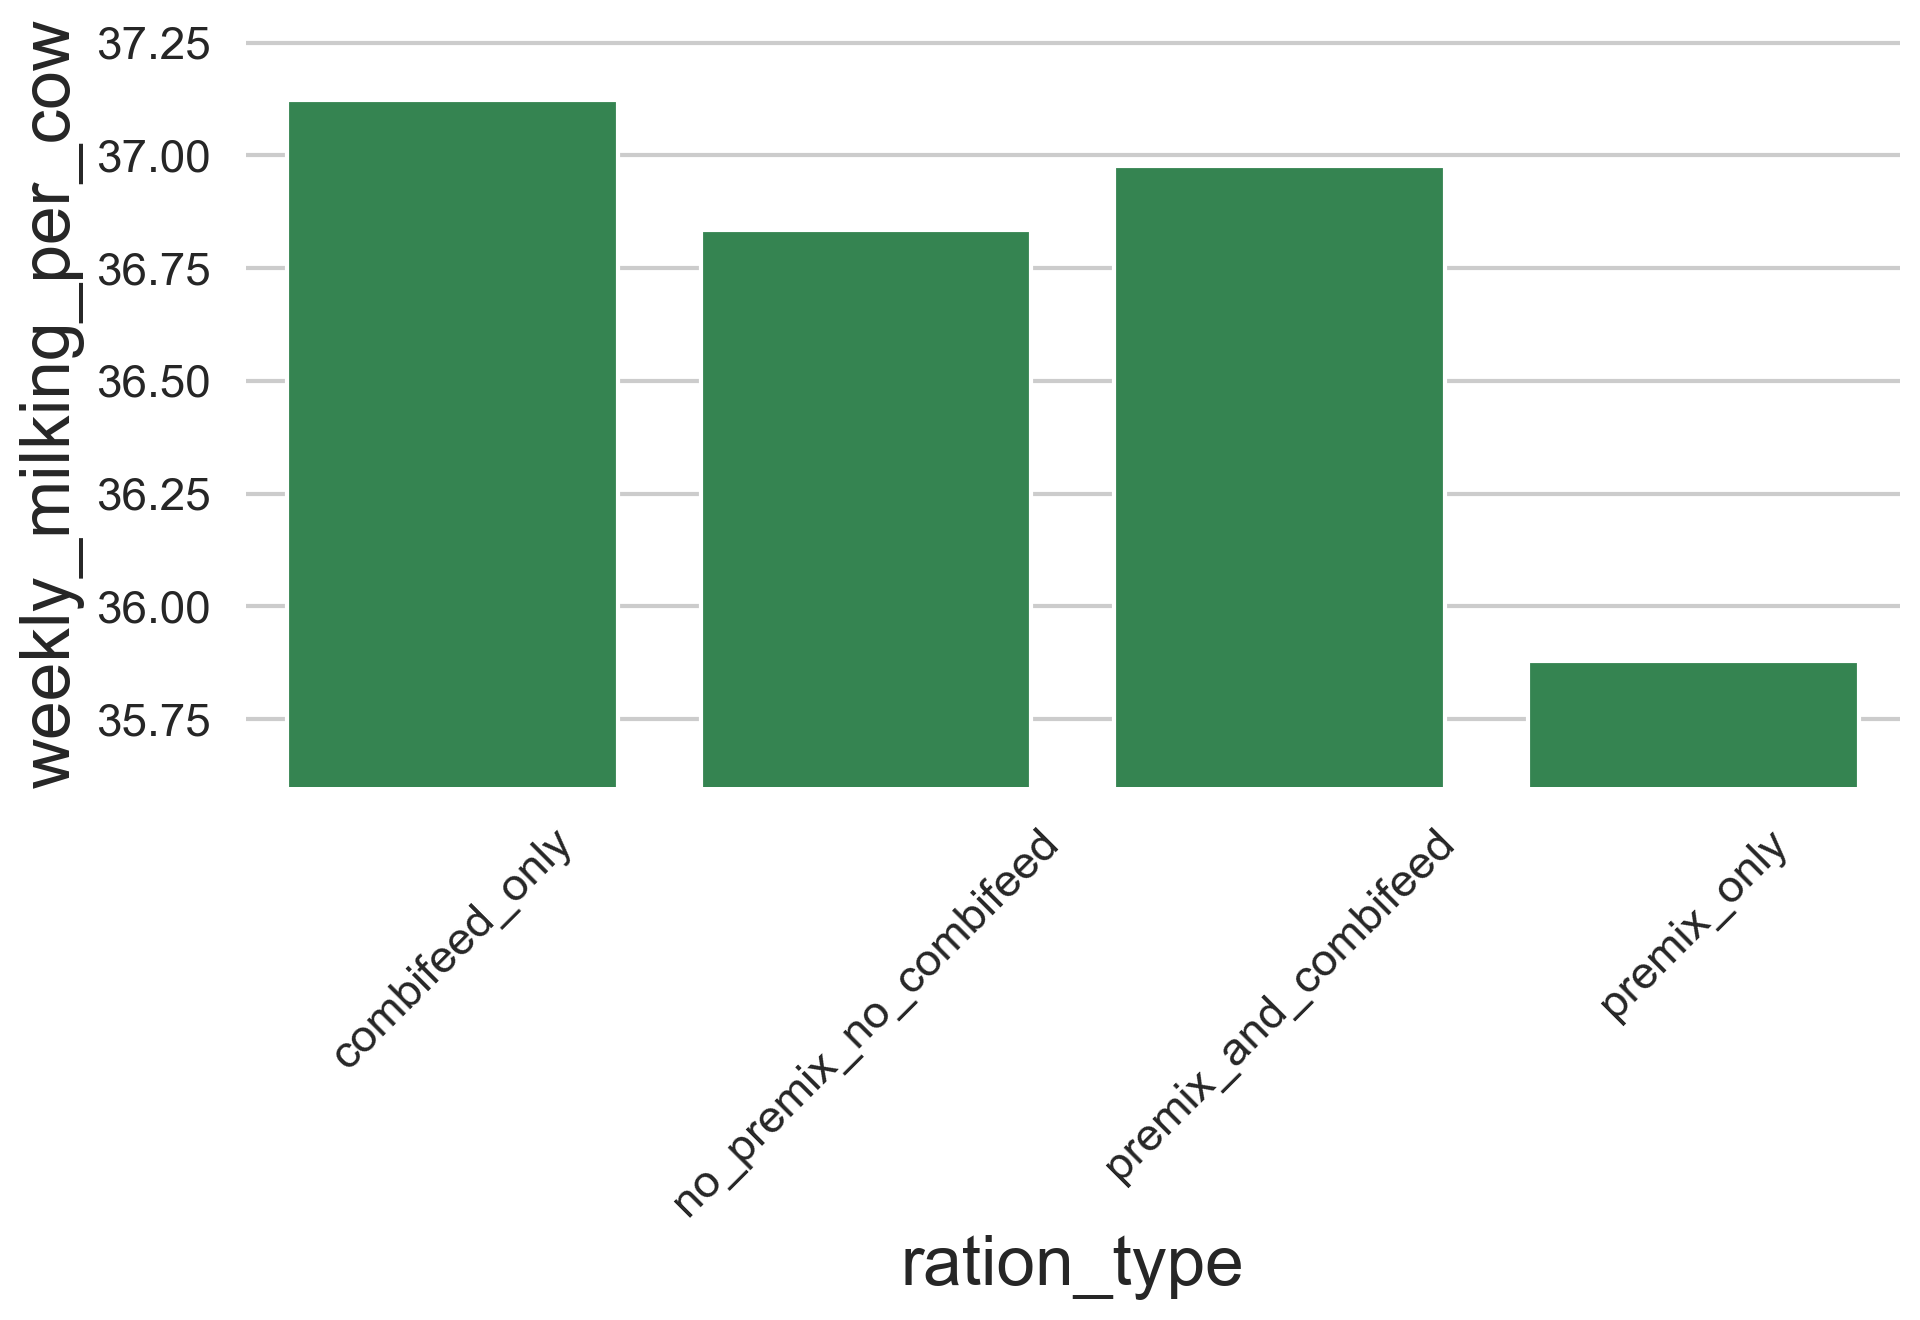

In [69]:
sns.barplot(data=dd.groupby('ration_type')['weekly_milking_per_cow'].mean().reset_index(), x='ration_type', y='weekly_milking_per_cow')
plt.ylim(35.6, 37.3)
plt.xticks(rotation=45);

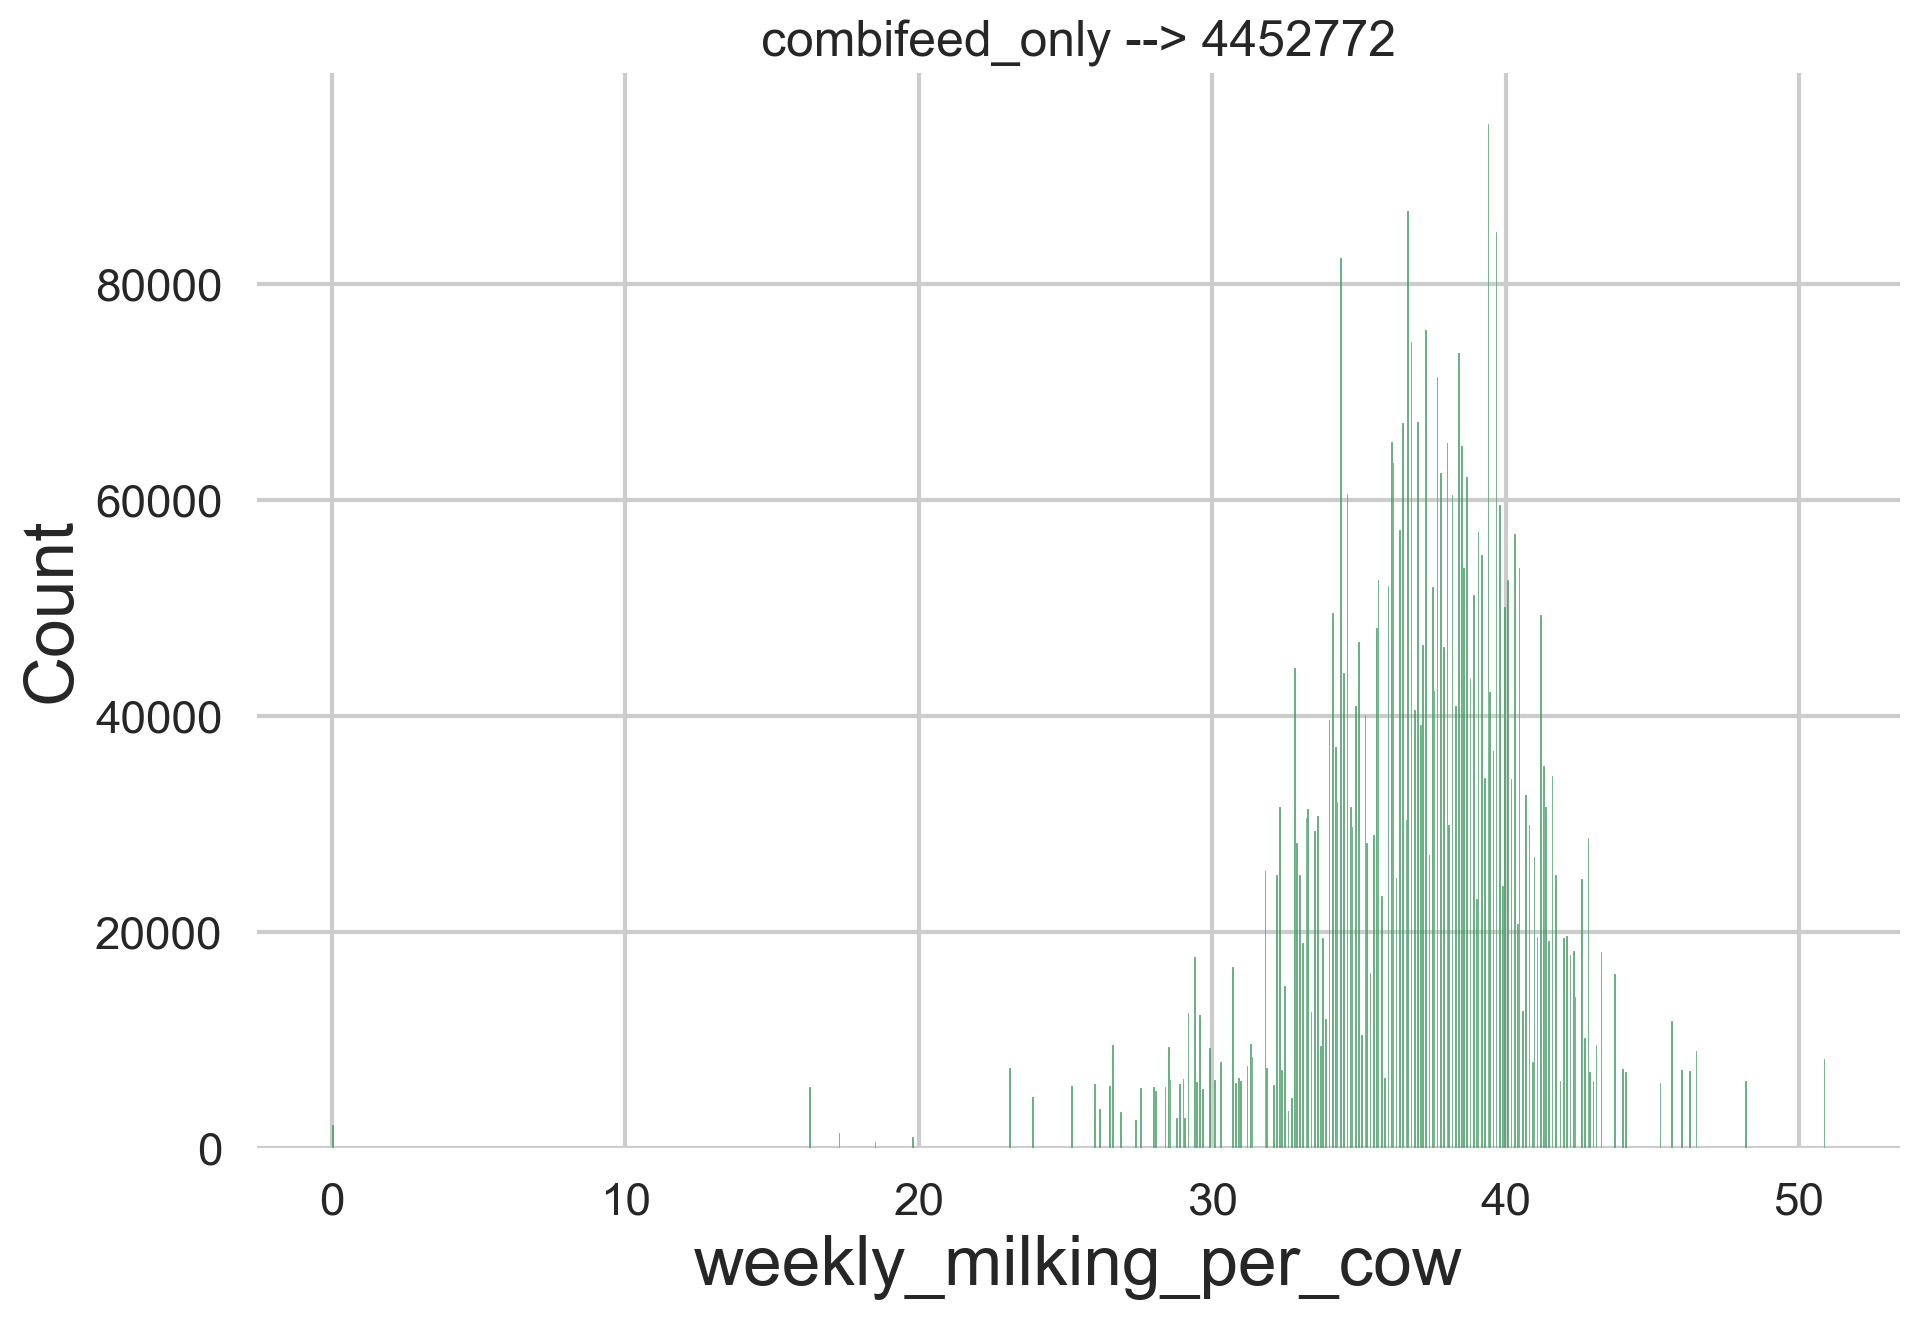

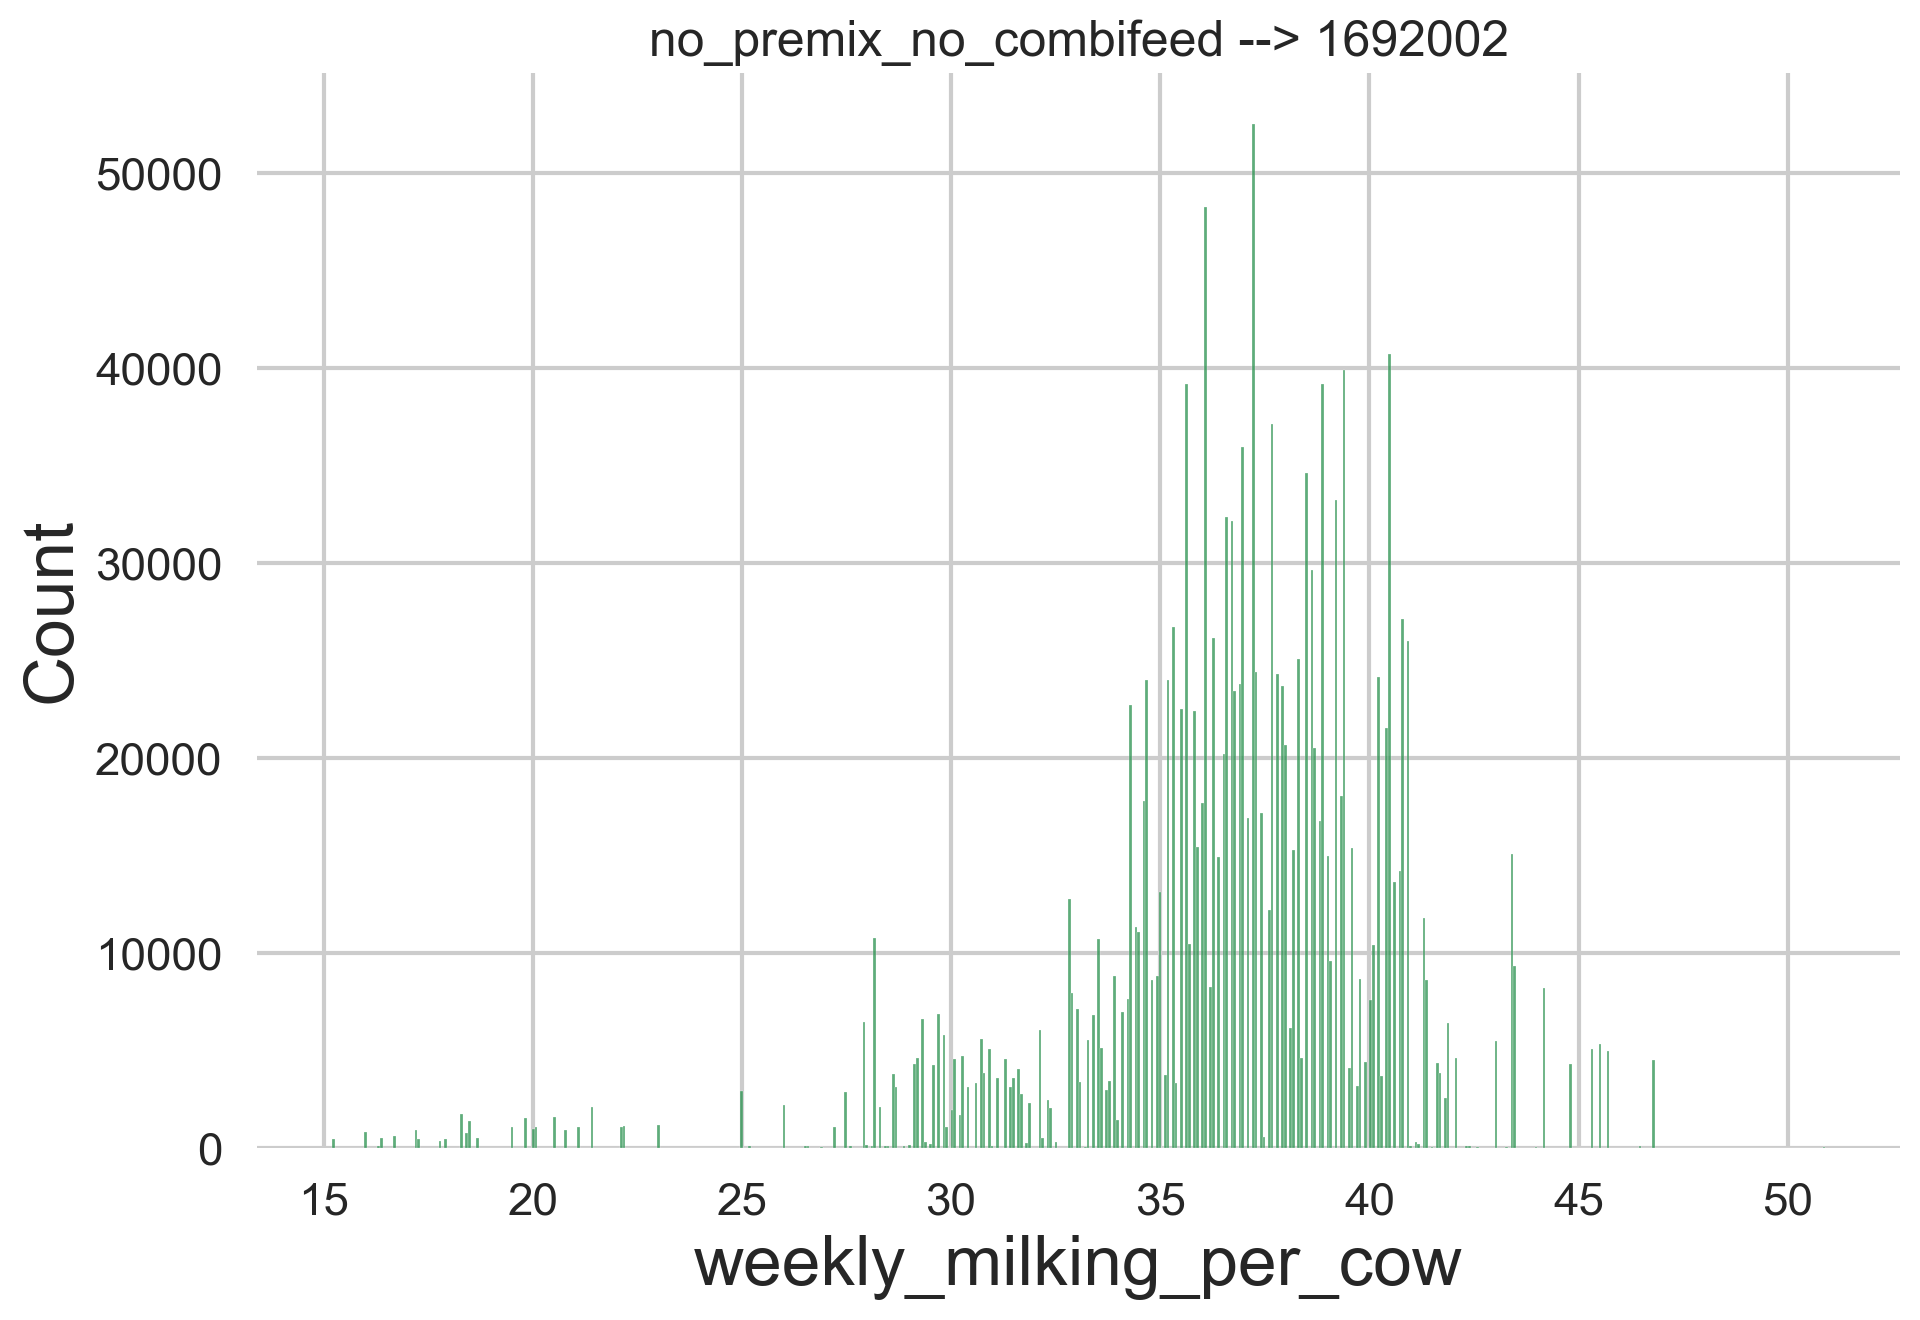

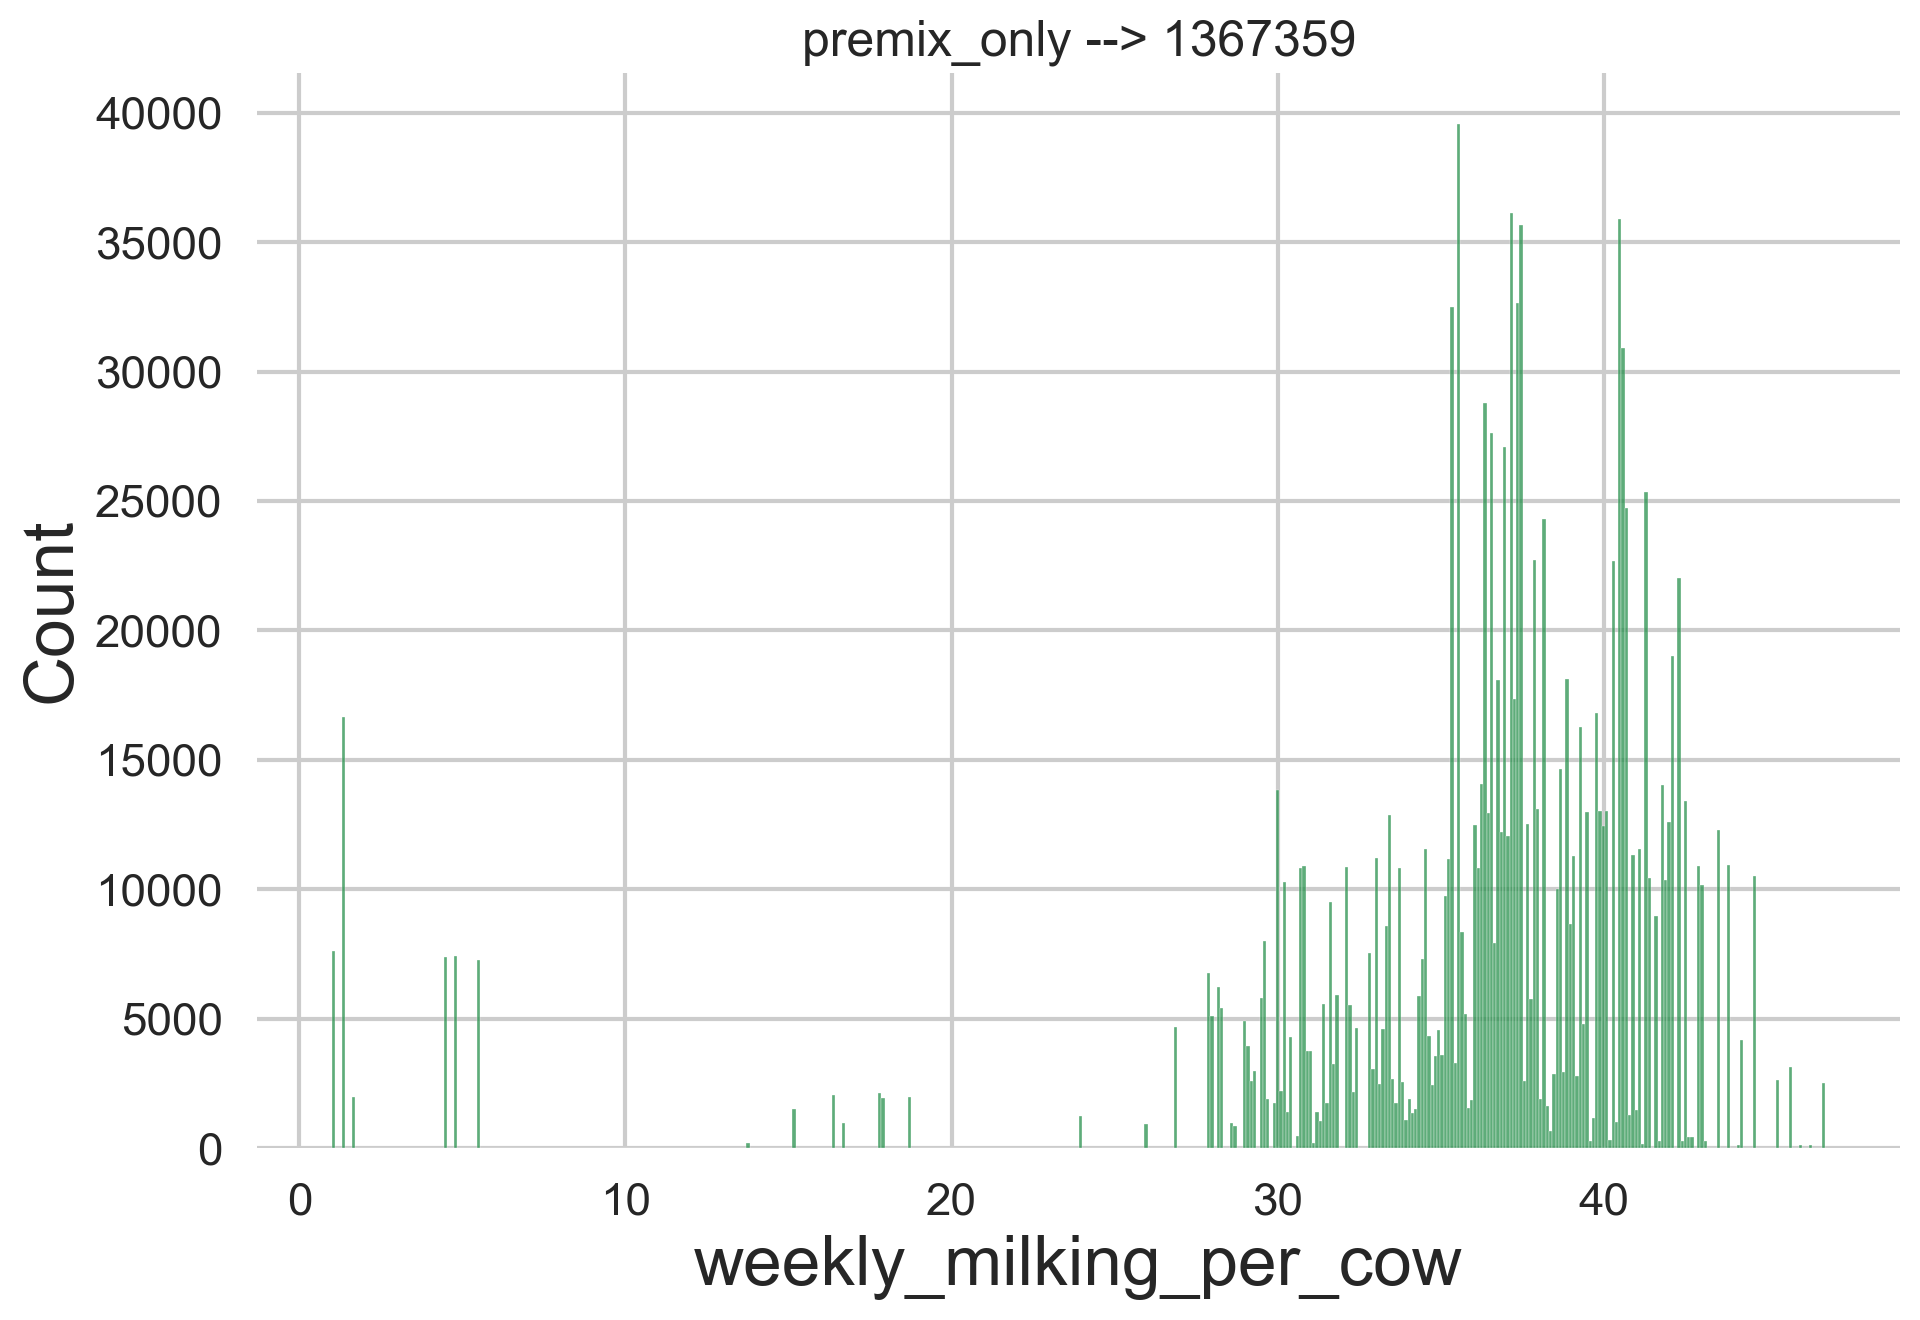

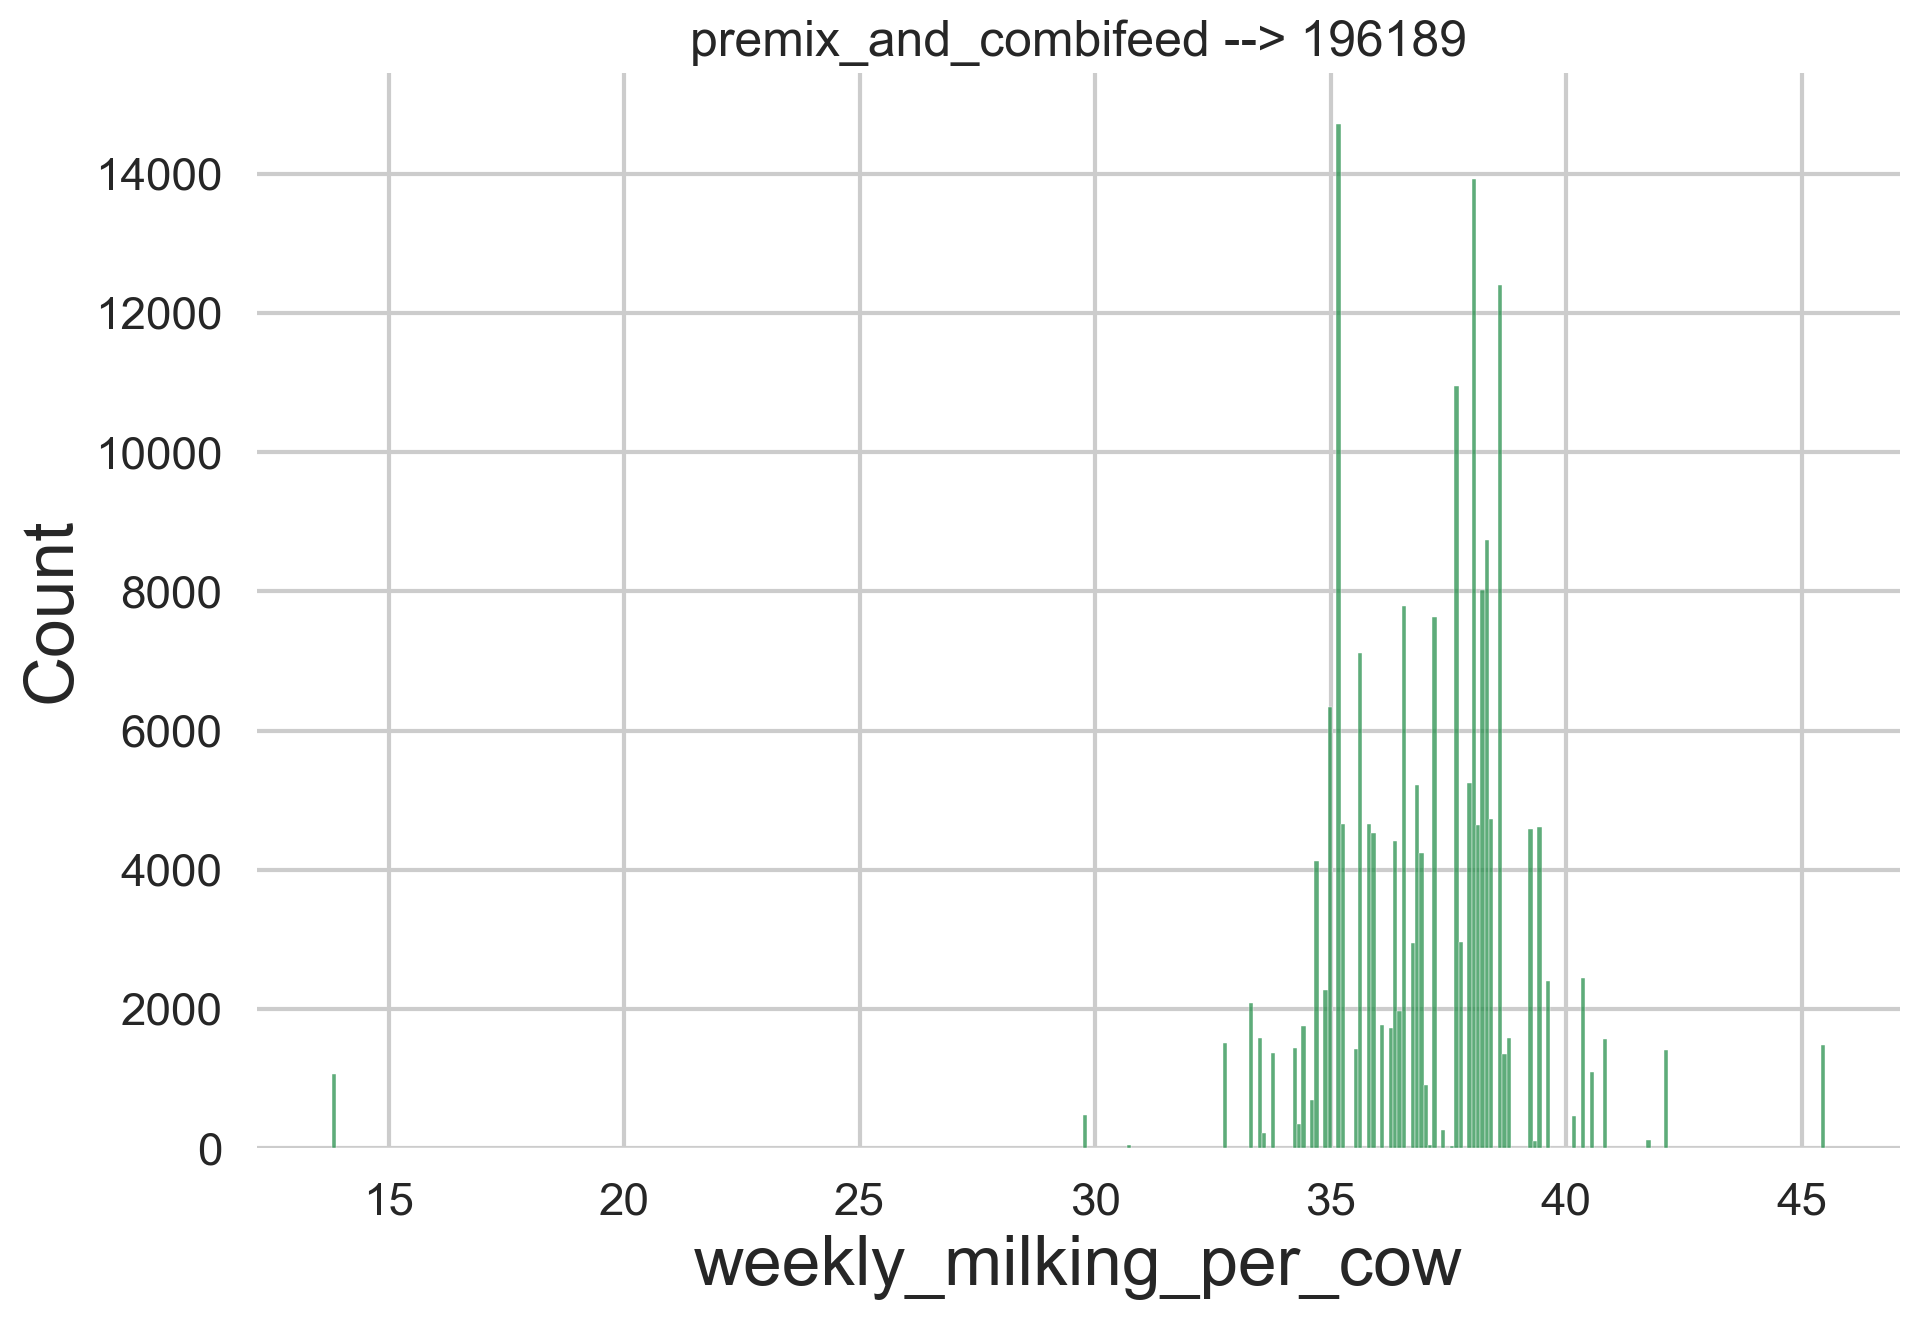

In [74]:
for rt in dd['ration_type'].unique():
    plt.subplots()
    dd2 = dd[dd['ration_type'] == rt]
    sns.histplot(data=dd2, x='weekly_milking_per_cow')
    plt.title(f'{rt} --> {dd2.shape[0]}', fontsize=18)

In [75]:
df = dd.copy()
df['weekly_milking_per_cow'] = pd.to_numeric(df['weekly_milking_per_cow'], errors='coerce')
df = df.dropna(subset=['weekly_milking_per_cow', 'ration_type'])

In [76]:
from scipy.stats import f_oneway

groups = [
    g['weekly_milking_per_cow'].values
    for _, g in df.groupby('ration_type')
]

f_stat, p_val = f_oneway(*groups)

print("ANOVA F =", f_stat)
print("ANOVA p =", p_val)

ANOVA F = 25166.400495110895
ANOVA p = 0.0


In [77]:
from scipy.stats import kruskal

kw_stat, kw_p = kruskal(*groups)

print("Kruskal–Wallis H =", kw_stat)
print("Kruskal p =", kw_p)

Kruskal–Wallis H = 5397.776138138839
Kruskal p = 0.0
